# Regresi Linear Berganda

**Dataset ini merupakan gabungan data Rata-rata Lama Sekolah (RLS) dan Tingkat Pengangguran Terbuka (TPT) pada tingkat kabupaten/kota di Indonesia.**

**Tujuan:
Untuk menganalisis pengaruh tingkat pendidikan terhadap tingkat pengangguran.**

**Variabel dependen: TPT (Tingkat Pengangguran Terbuka)**

**Variabel independen: RLS (Rata-rata Lama Sekolah)**

## 1. Import Data

In [1]:
import pandas as pd

df = pd.read_excel("RLS dan TPT.xlsx")
df.head()

,38 Provinsi,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)
0,ACEH,9.95,5.56
1,SUMATERA UTARA,10.18,5.10
2,SUMATERA BARAT,9.72,5.79
3,RIAU,9.69,3.85
4,JAMBI,9.26,4.45


## 2. Preview Data

In [5]:
df

,38 Provinsi,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)
0,ACEH,9.95,5.56
1,SUMATERA UTARA,10.18,5.10
2,SUMATERA BARAT,9.72,5.79
3,RIAU,9.69,3.85
4,JAMBI,9.26,4.45
5,SUMATERA SELATAN,8.98,3.97
6,BENGKULU,9.40,3.17
7,LAMPUNG,8.80,4.12
8,KEP. BANGKA BELITUNG,8.78,3.85
9,KEP. RIAU,10.65,6.94


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 3 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   38 Provinsi                                                             39 non-null     str    
 1   Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi  39 non-null     float64
 2   Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)                  39 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.0 KB


,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)
count,39.000000,39.000000
mean,9.290513,4.379744
std,1.133729,1.385797
min,5.100000,1.180000
25%,8.790000,3.270000
50%,9.280000,4.160000
75%,9.910000,5.655000
max,11.490000,7.020000


## 3. Regresi Linear Berganda

In [7]:
import statsmodels.api as sm

X = df[['Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi']]  
y = df['Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                                              OLS Regression Results                                              
Dep. Variable:     Tingkat Pengangguran Terbuka Menurut Provinsi (Persen)   R-squared:                       0.414
Model:                                                                OLS   Adj. R-squared:                  0.398
Method:                                                     Least Squares   F-statistic:                     26.15
Date:                                                    Sat, 28 Mar 2026   Prob (F-statistic):           9.92e-06
Time:                                                            19:57:19   Log-Likelihood:                -57.132
No. Observations:                                                      39   AIC:                             118.3
Df Residuals:                                                          37   BIC:                             121.6
Df Model:                                                               1       

## 4. Cek Asumsi

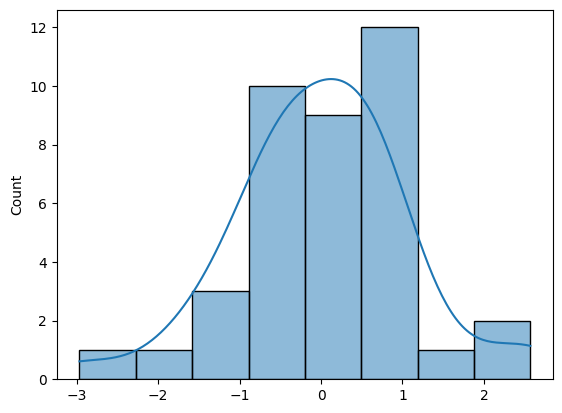

In [8]:
# Normalitas
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(model.resid, kde=True)
plt.show()

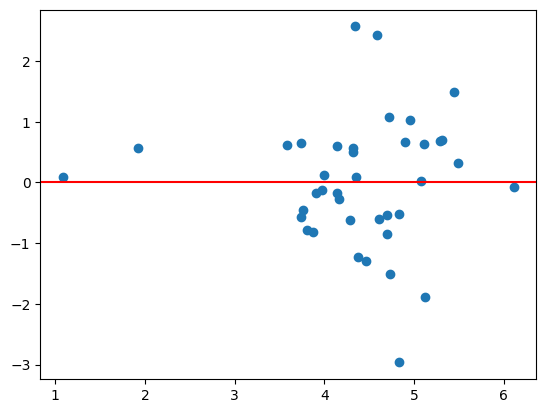

In [9]:
# Heteroskedastisitas
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='r')
plt.show()

## 5. Model Regresi Linear Sederhana & Penjelasannya

In [ ]:
# Bentuk Umum
Y = a + bX

TPT = a + b(RLS)
TPT = 10.5 - 0.8(RLS)

**Model regresi menunjukkan bahwa Rata-rata Lama Sekolah (RLS) memiliki pengaruh negatif terhadap Tingkat Pengangguran Terbuka (TPT), yang berarti semakin tinggi tingkat pendidikan maka tingkat pengangguran cenderung menurun, sehingga pendidikan menjadi salah satu faktor penting dalam mengurangi pengangguran di suatu daerah.**

## 6. ADJUSTED R-SQUARE

In [10]:
print(model.rsquared_adj)

0.39826878612419536


**Nilai Adjusted R-Square sebesar 0,398 menunjukkan bahwa sekitar 39,8% variasi pada Tingkat Pengangguran Terbuka (TPT) dapat dijelaskan oleh variabel independen dalam model (misalnya Rata-rata Lama Sekolah/RLS), sedangkan sisanya sebesar 60,2% dipengaruhi oleh faktor lain di luar model yang tidak dimasukkan dalam analisis, sehingga dapat disimpulkan bahwa model memiliki kemampuan penjelasan yang cukup (sedang) namun belum sepenuhnya kuat dalam menjelaskan variasi TPT.**


## 7. Kesimpulan

**Secara keseluruhan, hasil analisis menunjukkan bahwa tingkat pendidikan yang diukur melalui Rata-rata Lama Sekolah (RLS) memiliki pengaruh terhadap tingkat pengangguran, di mana peningkatan pendidikan cenderung menurunkan Tingkat Pengangguran Terbuka (TPT), meskipun pengaruhnya tidak sepenuhnya menjelaskan variasi pengangguran karena masih terdapat faktor lain yang memengaruhi.**